BASE = C:\Users\hsofi\EVC\evc_project\bidding_strategy

=== Running: CAISO DLAP_PGAE-APND ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\CAISO\df_DA_CAISO_DLAP_PGAE-APND_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\CAISO\df_RT_CAISO_DLAP_PGAE-APND_2025_RT_5min.csv

=== Running: CAISO DLAP_SCE-APND ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\CAISO\df_DA_CAISO_DLAP_SCE-APND_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\CAISO\df_RT_CAISO_DLAP_SCE-APND_2025_RT_5min.csv

=== Running: CAISO DLAP_SDGE-APND ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\CAISO\df_DA_CAISO_DLAP_SDGE-APND_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\CAISO\df_RT_CAISO_DLAP_SDGE-APND_2025_RT_5min.csv

=== Running: CAISO DLAP_VEA-APND ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\CAISO\df_DA_CAISO_DLAP_VEA-APND_

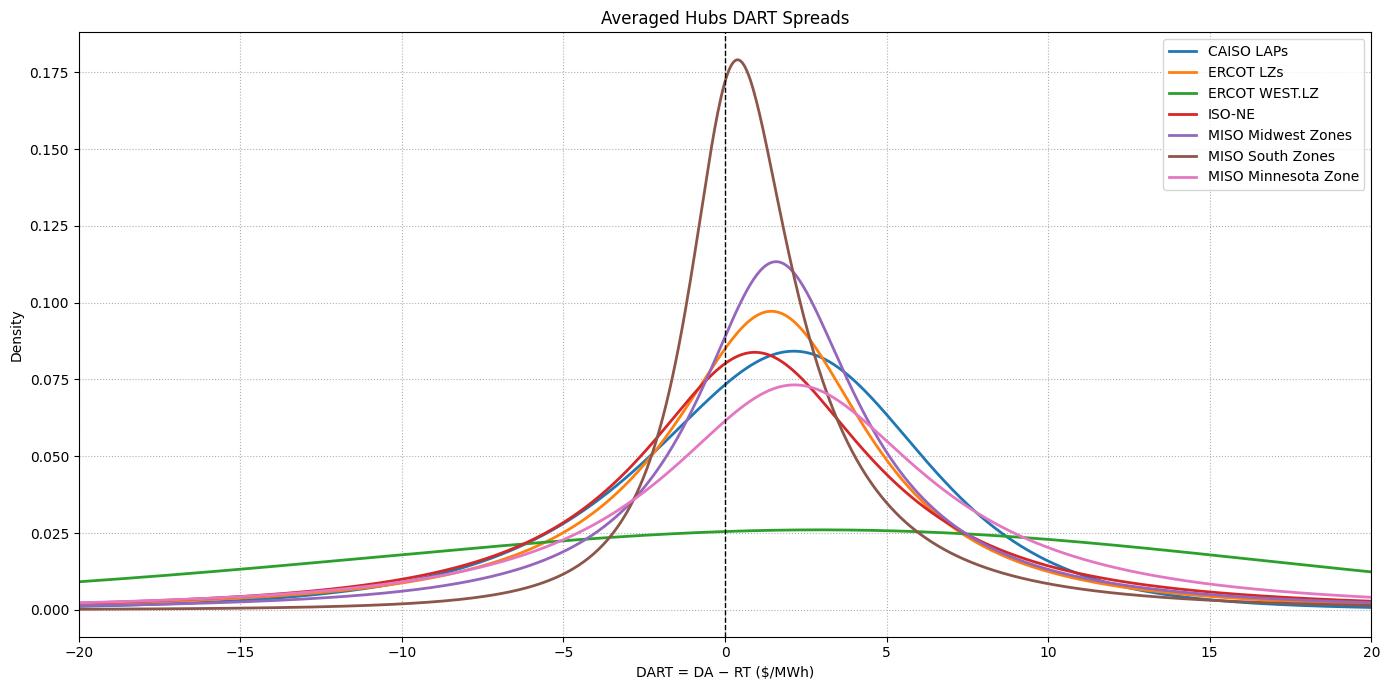

In [2]:
# =========================================================
# DART EV-window metrics + GROUP-AVERAGE (Zones vs GEN HUBs)
# Uses BASE = Path.cwd() + relative paths (NO C:\ hard-coding)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# --- project root (where DA_LMPs_Data/ and RT_LMPs_Data/ folders live) ---
BASE = Path.cwd()

def p(*parts) -> str:
    """Build a path relative to BASE."""
    return str(BASE.joinpath(*parts))


# =========================================================
# 1) I/O helpers (robust: handles "CSV saved as .xls")
# =========================================================
def load_table(path: str) -> pd.DataFrame:
    """
    Load CSV / XLS / XLSX based on extension, but also handles the common case
    where a file is CSV text but saved with .xls extension.
    """
    fp = Path(path)
    if not fp.exists():
        raise FileNotFoundError(
            f"File not found:\n{fp}\n\nBASE is:\n{BASE}\n"
            f"Tip: make sure DA_LMPs_Data/ and RT_LMPs_Data/ are inside BASE."
        )

    pth = path.lower()

    # sniff first chunk (to detect CSV text misnamed as .xls)
    head = fp.read_bytes()[:2048]
    try:
        txt = head.decode("utf-8", errors="strict")
        if ("," in txt and "\n" in txt) or ("\t" in txt and "\n" in txt) or (";" in txt and "\n" in txt):
            delim_counts = {",": txt.count(","), "\t": txt.count("\t"), ";": txt.count(";")}
            sep = max(delim_counts, key=delim_counts.get)
            return pd.read_csv(path, sep=sep, low_memory=False)
    except Exception:
        pass

    if pth.endswith(".csv"):
        return pd.read_csv(path, low_memory=False)

    if pth.endswith((".xls", ".xlsx")):
        for engine in ["openpyxl", "xlrd"]:
            try:
                return pd.read_excel(path, engine=engine)
            except Exception:
                pass
        try:
            tables = pd.read_html(path)
            if tables:
                return tables[0]
        except Exception:
            pass
        raise ValueError(f"Excel file format cannot be determined for: {path}")

    raise ValueError(f"Unsupported file type: {path}")


def _get_time_col(df: pd.DataFrame) -> str:
    for c in [
        "interval_start_utc", "interval_start", "time", "timestamp", "datetime",
        "Interval Start", "IntervalStart", "interval_start_time_utc", "IntervalStartUTC"
    ]:
        if c in df.columns:
            return c
    for c in df.columns:
        try:
            if np.issubdtype(df[c].dtype, np.datetime64):
                return c
        except Exception:
            pass
    raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))


def _pick_price_col(df: pd.DataFrame, preferred: str) -> str:
    if preferred in df.columns:
        return preferred

    lower_map = {str(c).lower(): c for c in df.columns}
    if preferred.lower() in lower_map:
        return lower_map[preferred.lower()]

    candidates = [
        "price", "lmp", "da_lmp", "rt_lmp",
        "lbmp", "mp", "value",
        "settlement_point_price", "settlement_point_price_dollar_per_mwh",
        "market_price"
    ]
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower_map:
            return lower_map[c.lower()]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for c in numeric_cols:
        if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
            return c

    raise KeyError(f"Could not find a price column. Columns are:\n{list(df.columns)}")


# =========================================================
# 2) Core: compute DART hourly (DA - RT hourly)
# =========================================================
def compute_dart_hourly(
    df_rt: pd.DataFrame,
    df_da: pd.DataFrame,
    price_col="lmp",
    clip_low=-100,
    clip_high=100,
    tz_plot="America/New_York",
    rt_hourly_method="mean",
    verbose=False,
) -> pd.DataFrame:
    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)
    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] time col: '{da_time_col}', price col: '{da_price_col}'")

    # RT
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)
    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")
    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # DA
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)
    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})
    da_h = da.resample("h").mean()

    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]
    return merged


def filter_charging_window(df: pd.DataFrame, start_hour=0, end_hour=6) -> pd.DataFrame:
    h = df.index.hour
    return df[(h >= start_hour) & (h < end_hour)]


def compute_ev_window_metrics(
    dart_hourly: pd.DataFrame,
    start_hour=0,
    end_hour=6,
    block_hours=6,
    cvar_alpha=0.10,
) -> dict:
    win = filter_charging_window(dart_hourly, start_hour, end_hour).copy()
    w = win["DA_minus_RT"].dropna()

    dart_hourly = dart_hourly.copy()
    dart_hourly["roll_mean"] = dart_hourly["DA_minus_RT"].rolling(block_hours).mean()
    dart_hourly["roll_std"]  = dart_hourly["DA_minus_RT"].rolling(block_hours).std()

    win["date_local"] = win.index.date
    nightly = win.groupby("date_local")["DA_minus_RT"].agg(["mean", "std", "count"])
    nightly = nightly.rename(columns={"mean": "night_mean", "std": "night_std", "count": "night_nhours"})

    mean_w = float(w.mean()) if len(w) else np.nan
    std_w  = float(w.std())  if len(w) else np.nan
    sharpe_like = (mean_w / std_w) if (std_w and std_w > 0) else np.nan

    p_pos_hour = float((w > 0).mean()) if len(w) else np.nan
    p_neg_hour = float((w < 0).mean()) if len(w) else np.nan

    roll_win = filter_charging_window(dart_hourly.dropna(subset=["roll_mean"]), start_hour, end_hour)
    roll_mean_avg = float(roll_win["roll_mean"].mean()) if len(roll_win) else np.nan
    p_pos_block   = float((roll_win["roll_mean"] > 0).mean()) if len(roll_win) else np.nan

    if len(w):
        q = w.quantile(cvar_alpha)
        cvar = float(w[w <= q].mean()) if np.isfinite(q) else np.nan
    else:
        cvar = np.nan

    if len(nightly) and nightly["night_mean"].notna().any():
        qn = nightly["night_mean"].quantile(cvar_alpha)
        cvar_night = float(nightly.loc[nightly["night_mean"] <= qn, "night_mean"].mean())
    else:
        cvar_night = np.nan

    return {
        "start_hour": start_hour,
        "end_hour": end_hour,
        "block_hours": block_hours,
        "cvar_alpha": cvar_alpha,

        "mean_dart_window": mean_w,
        "std_dart_window": std_w,
        "sharpe_like_window": sharpe_like,
        "p_positive_hour_window": p_pos_hour,
        "p_negative_hour_window": p_neg_hour,
        "cvar_hourly_window": cvar,

        "roll_mean_avg_window": roll_mean_avg,
        "p_profitable_block_window": p_pos_block,
        "cvar_nightly_mean": cvar_night,

        "dart_hourly": dart_hourly,
        "window_hourly": win,
        "nightly_blocks": nightly,
    }


# =========================================================
# 3) Build all_metrics from CASES
# =========================================================
def build_all_metrics_from_cases(
    CASES,
    START_HOUR=0,
    END_HOUR=6,
    BLOCK_HOURS=6,
    CVAR_ALPHA=0.10,
    CLIP_LOW=-100,
    CLIP_HIGH=100,
    PRICE_COL="lmp",
    RT_HOURLY_METHOD="mean",
    verbose=False,
):
    summary_rows = []
    nightly_dict = {}
    all_metrics = {}

    print("BASE =", BASE)

    for name, da_path, rt_path, tz in CASES:
        print(f"\n=== Running: {name} ===")
        print("DA:", da_path)
        print("RT:", rt_path)

        df_DA = load_table(da_path)
        df_RT = load_table(rt_path)

        dart_hourly = compute_dart_hourly(
            df_rt=df_RT,
            df_da=df_DA,
            price_col=PRICE_COL,
            clip_low=CLIP_LOW,
            clip_high=CLIP_HIGH,
            tz_plot=tz,
            rt_hourly_method=RT_HOURLY_METHOD,
            verbose=verbose,
        )

        metrics = compute_ev_window_metrics(
            dart_hourly=dart_hourly,
            start_hour=START_HOUR,
            end_hour=END_HOUR,
            block_hours=BLOCK_HOURS,
            cvar_alpha=CVAR_ALPHA,
        )

        all_metrics[name] = metrics
        nightly_dict[name] = metrics["nightly_blocks"]

        summary_rows.append({
            "iso_hub": name,
            "mean_dart_window": metrics["mean_dart_window"],
            "std_dart_window": metrics["std_dart_window"],
            "sharpe_like_window": metrics["sharpe_like_window"],
            "p_positive_hour_window": metrics["p_positive_hour_window"],
            "p_profitable_block_window": metrics["p_profitable_block_window"],
            "cvar_hourly_window": metrics["cvar_hourly_window"],
            "cvar_nightly_mean": metrics["cvar_nightly_mean"],
            "n_hours_window": len(metrics["window_hourly"]),
            "n_nights": len(metrics["nightly_blocks"]),
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .set_index("iso_hub")
        .sort_values("sharpe_like_window", ascending=False)
    )

    print("\n=== Cross-ISO Summary (EV window) ===")
    print(summary_df)

    return all_metrics, summary_df, nightly_dict


# =========================================================
# 4) GROUP-AVERAGE best-fit plotting (ONLY 2 curves: zones vs hubs)
#    "Average curve" here means: pool data across the group and fit 1 dist.
# =========================================================
def plot_group_average_best_fit(
    all_metrics: dict,
    groups: dict,
    which="hourly",
    xlim=(-20, 20),
    npoints=800,
    criterion="AIC",
    hide_exact_zeros=True,
    zero_tol=0.0,
    min_n=200,
    candidates=("t", "skewnorm", "norm", "johnsonsu"),
):
    dist_map = {
        "norm": stats.norm,
        "t": stats.t,
        "skewnorm": stats.skewnorm,
        "johnsonsu": stats.johnsonsu,
    }
    candidates = [c for c in candidates if c in dist_map]
    if not candidates:
        raise ValueError("No valid candidates. Use one of: " + ", ".join(dist_map.keys()))
    if criterion not in ("AIC", "BIC"):
        raise ValueError("criterion must be 'AIC' or 'BIC'")

    def _get_series(m):
        if which == "hourly":
            return m["window_hourly"]["DA_minus_RT"].dropna()
        if which == "nightly":
            return m["nightly_blocks"]["night_mean"].dropna()
        raise ValueError("which must be 'hourly' or 'nightly'")

    def _filter_for_fit(s):
        x = np.asarray(s, dtype=float)
        x = x[np.isfinite(x)]
        if not hide_exact_zeros:
            return x
        if zero_tol == 0.0:
            return x[x != 0.0]
        return x[np.abs(x) > zero_tol]

    def _fit_and_score(dist, x):
        params = dist.fit(x)
        logpdf = dist.logpdf(x, *params)
        if not np.all(np.isfinite(logpdf)):
            return None
        ll = float(np.sum(logpdf))
        k = len(params)
        n = len(x)
        aic = 2 * k - 2 * ll
        bic = k * np.log(n) - 2 * ll
        return {"params": params, "ll": ll, "AIC": aic, "BIC": bic}

    # ---- pool samples per group ----
    pooled = {}
    for gname, selector in groups.items():
        xs = []
        for name, m in all_metrics.items():
            if selector(name):
                xs.append(_get_series(m))
        if xs:
            pooled[gname] = _filter_for_fit(pd.concat(xs, axis=0))

    # ---- fit best per group ----
    fits = {}
    for gname, x in pooled.items():
        if len(x) < min_n:
            print(f"[SKIP] {gname}: not enough samples (n={len(x)} < {min_n})")
            continue

        best_row = None
        for dname in candidates:
            dist = dist_map[dname]
            try:
                row = _fit_and_score(dist, x)
                if row is None:
                    continue
                row["dist_name"] = dname
                if (best_row is None) or (row[criterion] < best_row[criterion]):
                    best_row = row
            except Exception:
                continue

        if best_row is None:
            print(f"[FAIL] {gname}: all fits failed")
            continue

        fits[gname] = best_row
        print(f"[{gname}] best={best_row['dist_name']} | n={len(x)} | AIC={best_row['AIC']:.1f} | BIC={best_row['BIC']:.1f}")

    if not fits:
        print("No group had enough data (or all fits failed).")
        return

    # ---- plot ONLY group curves ----
    xx = np.linspace(xlim[0], xlim[1], npoints)
    plt.figure(figsize=(14, 7))

    for gname, row in fits.items():
        dist = dist_map[row["dist_name"]]
        pdf = dist.pdf(xx, *row["params"])
        if np.all(np.isfinite(pdf)):
            plt.plot(xx, pdf, linewidth=2, label=gname)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.xlim(*xlim)
    plt.xlabel("DART = DA − RT ($/MWh)" if which == "hourly" else "Nightly mean DART ($/MWh)")
    plt.ylabel("Density")
    plt.title("Averaged Hubs DART Spreads")
    plt.grid(True, linestyle=":")
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


# =========================================================
# 5) CASES (YOUR PJM HUBS)
# =========================================================
CASES = [
    ("CAISO DLAP_PGAE-APND",
     p("DA_LMPs_Data","CAISO","df_DA_CAISO_DLAP_PGAE-APND_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","CAISO","df_RT_CAISO_DLAP_PGAE-APND_2025_RT_5min.csv"),
     "America/Los_Angeles"),

    ("CAISO DLAP_SCE-APND",
     p("DA_LMPs_Data","CAISO","df_DA_CAISO_DLAP_SCE-APND_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","CAISO","df_RT_CAISO_DLAP_SCE-APND_2025_RT_5min.csv"),
     "America/Los_Angeles"),

    ("CAISO DLAP_SDGE-APND",
     p("DA_LMPs_Data","CAISO","df_DA_CAISO_DLAP_SDGE-APND_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","CAISO","df_RT_CAISO_DLAP_SDGE-APND_2025_RT_5min.csv"),
     "America/Los_Angeles"),

    ("CAISO DLAP_VEA-APND",
     p("DA_LMPs_Data","CAISO","df_DA_CAISO_DLAP_VEA-APND_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","CAISO","df_RT_CAISO_DLAP_VEA-APND_2025_RT_5min.csv"),
     "America/Los_Angeles"),

        ("ERCOT AEN.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_AEN.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_AEN.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

     ("ERCOT CPS.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_CPS.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_CPS.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

     ("ERCOT LCRA.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_LCRA.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_LCRA.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

     ("ERCOT HOUSTON.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_HOUSTON.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_HOUSTON.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

     #("ERCOT HOUSTON.HUB",
     #p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_HOUSTON.HUB_2025_DA_hourly.csv"),
     #p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_HOUSTON.HUB_2025_RT_5min.csv"),
     #"America/Chicago"),

     #("ERCOT NORTH.HUB",
     #p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_NORTH.HUB_2025_DA_hourly.csv"),
     #p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_NORTH.HUB_2025_RT_5min.csv"),
     #"America/Chicago"),

     ("ERCOT NORTH.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_NORTH.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_NORTH.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

     ("ERCOT SOUTH.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_SOUTH.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_SOUTH.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

    #("ERCOT SOUTH.HUB",
     #p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_SOUTH.HUB_2025_DA_hourly.csv"),
     #p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_SOUTH.HUB_2025_RT_5min.csv"),
    #"America/Chicago"),

    ("ERCOT WEST.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_WEST.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_WEST.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

     #("ERCOT WEST.HUB",
     #p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_WEST.HUB_2025_DA_hourly.csv"),
     #p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_WEST.HUB_2025_RT_5min.csv"),
     #"America/Chicago"),

    #("ERCOT PAN.HUB",
     #p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_PAN.HUB_2025_DA_hourly.csv"),
     #p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_PAN.HUB_2025_RT_5min.csv"),
     #"America/Chicago"),

    ("ERCOT RAYBN.LZ",
     p("DA_LMPs_Data","ERCOT","df_DA_ERCOT_RAYBN.LZ_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ERCOT","df_RT_ERCOT_RAYBN.LZ_2025_RT_5min.csv"),
     "America/Chicago"),

    ("ISO-NE Z.CONNECTICUT",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.CONNECTICUT_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.CONNECTICUT_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.MAINE",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.MAINE_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.MAINE_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.NEMASSBOST",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.NEMASSBOST_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.NEMASSBOST_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.NEWHAMPSHIRE",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.NEWHAMPSHIRE_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.NEWHAMPSHIRE_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.RHODEISLAND",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.RHODEISLAND_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.RHODEISLAND_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.SEMASS",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.SEMASS_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.SEMASS_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.VERMONT",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.VERMONT_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.VERMONT_2025_RT_5min.csv"),
     "America/New_York"),

     ("ISO-NE Z.WCMASS",
     p("DA_LMPs_Data","ISO-NE","df_DA_ISONE_Z.WCMASS_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","ISO-NE","df_RT_ISONE_Z.WCMASS_2025_RT_5min.csv"),
     "America/New_York"),

    ("MISO ILLINOIS.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_ILLINOIS.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_ILLINOIS.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO ARKANSAS.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_ARKANSAS.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_ARKANSAS.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO INDIANA.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_INDIANA.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_INDIANA.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO LOUISIANA.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_LOUISIANA.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_LOUISIANA.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO MICHIGAN.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_MICHIGAN.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_MICHIGAN.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO MINN.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_MINN.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_MINN.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO MS.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_MS.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_MS.HUB_2025_RT_5min.csv"),
     "America/Chicago"),

    ("MISO TEXAS.HUB",
     p("DA_LMPs_Data","MISO","df_DA_MISO_TEXAS.HUB_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","MISO","df_RT_MISO_TEXAS.HUB_2025_RT_5min.csv"),
     "America/Chicago"),
]


# =========================================================
# 6) SETTINGS + RUN
# =========================================================
START_HOUR = 0
END_HOUR   = 6
BLOCK_HOURS = 6
CVAR_ALPHA = 0.10
CLIP_LOW = -100
CLIP_HIGH = 100
PRICE_COL = "lmp"
RT_HOURLY_METHOD = "mean"

all_metrics, summary_df, nightly_dict = build_all_metrics_from_cases(
    CASES,
    START_HOUR=START_HOUR,
    END_HOUR=END_HOUR,
    BLOCK_HOURS=BLOCK_HOURS,
    CVAR_ALPHA=CVAR_ALPHA,
    CLIP_LOW=CLIP_LOW,
    CLIP_HIGH=CLIP_HIGH,
    PRICE_COL=PRICE_COL,
    RT_HOURLY_METHOD=RT_HOURLY_METHOD,
    verbose=False,
)

# =========================================================
# 7) PLOT ONLY TWO CURVES:
#    - "Zones" = NOT GEN HUB
#    - "Hubs"  = GEN HUB
# =========================================================
groups = {
    "CAISO LAPs": lambda name: any(s in name for s in ["DLAP"]),
    "ERCOT LZs": lambda name: any(s in name for s in ["AEN.LZ","CPS.LZ","LCRA.LZ","HOUSTON.LZ","NORTH.LZ","SOUTH.LZ","RAYBN.LZ"]),
    "ERCOT WEST.LZ": lambda name: any(s in name for s in ["WEST.LZ"]),
    "ISO-NE": lambda name: any(s in name for s in ["Z."]),
    "MISO Midwest Zones": lambda name: any(s in name for s in ["ILLINOIS.HUB","INDIANA.HUB","MICHIGAN.HUB",]),
    "MISO South Zones": lambda name: any(s in name for s in ["LOUISIANA.HUB","ARKANSAS.HUB","TEXAS.HUB","MS.HUB"]),
    "MISO Minnesota Zone": lambda name: any(s in name for s in ["MINN.HUB"]),    
}

plot_group_average_best_fit(
    all_metrics,
    groups=groups,
    which="hourly",
    xlim=(-20, 20),
    criterion="AIC",
    min_n=200,
)


BASE = C:\Users\hsofi\EVC\evc_project\bidding_strategy

=== Running: PJM AECO ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\PJM\df_DA_PJM_AECO_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\PJM\df_RT_PJM_AECO_2025_RT_5min.csv

=== Running: PJM AEP ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\PJM\df_DA_PJM_AEP_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\PJM\df_RT_PJM_AEP_2025_RT_5min.csv

=== Running: PJM APS ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\PJM\df_DA_PJM_APS_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\PJM\df_RT_PJM_APS_2025_RT_5min.csv

=== Running: PJM ATSI ===
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\PJM\df_DA_PJM_ATSI_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\PJM\df_RT_PJM_ATSI_2025_RT_5min.csv

=== Running: PJM BGE ===
D

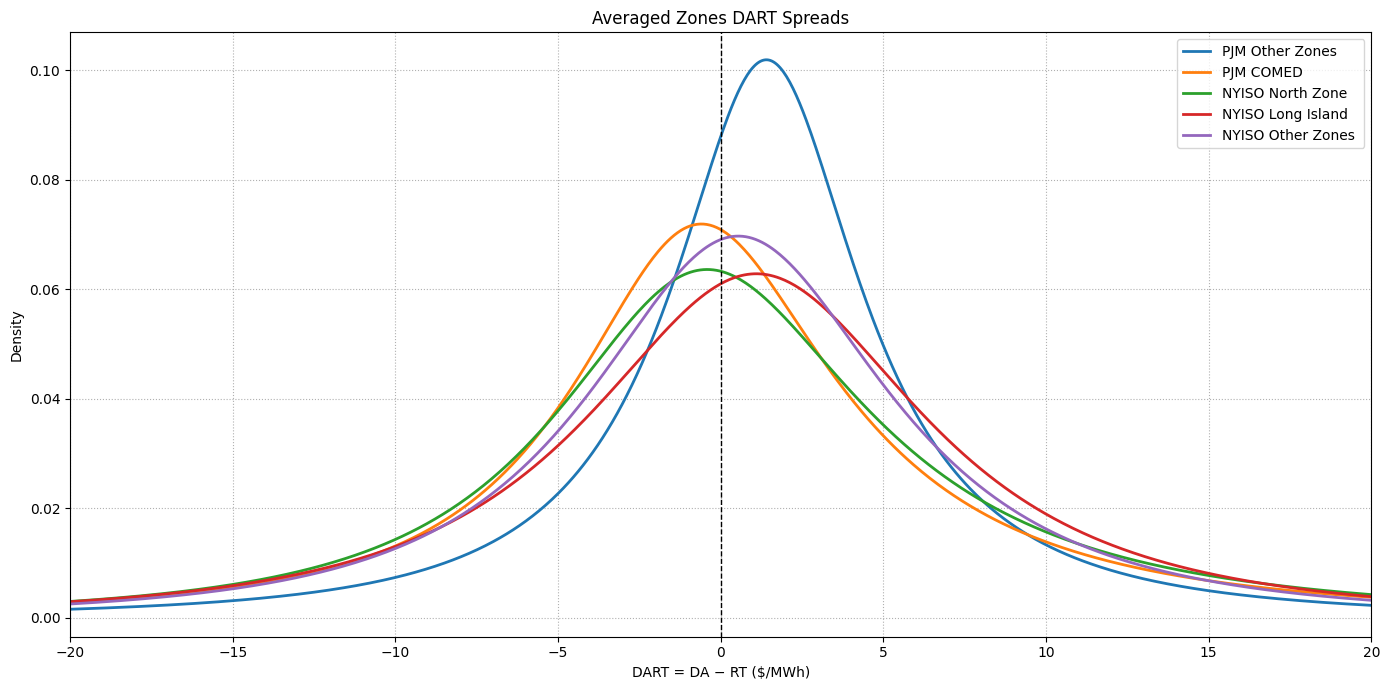

In [1]:
# =========================================================
# DART EV-window metrics + GROUP-AVERAGE (PJM ZONES)
# Uses BASE = Path.cwd() + relative paths (NO C:\ hard-coding)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

BASE = Path.cwd()

def p(*parts) -> str:
    return str(BASE.joinpath(*parts))

# =========================================================
# 1) I/O helpers
# =========================================================
def load_table(path: str) -> pd.DataFrame:
    fp = Path(path)
    if not fp.exists():
        raise FileNotFoundError(
            f"File not found:\n{fp}\n\nBASE is:\n{BASE}\n"
            f"Tip: make sure DA_LMPs_Data/ and RT_LMPs_Data/ are inside BASE."
        )

    pth = path.lower()

    head = fp.read_bytes()[:2048]
    try:
        txt = head.decode("utf-8", errors="strict")
        if ("," in txt and "\n" in txt) or ("\t" in txt and "\n" in txt) or (";" in txt and "\n" in txt):
            delim_counts = {",": txt.count(","), "\t": txt.count("\t"), ";": txt.count(";")}
            sep = max(delim_counts, key=delim_counts.get)
            return pd.read_csv(path, sep=sep, low_memory=False)
    except Exception:
        pass

    if pth.endswith(".csv"):
        return pd.read_csv(path, low_memory=False)

    if pth.endswith((".xls", ".xlsx")):
        for engine in ["openpyxl", "xlrd"]:
            try:
                return pd.read_excel(path, engine=engine)
            except Exception:
                pass
        try:
            tables = pd.read_html(path)
            if tables:
                return tables[0]
        except Exception:
            pass
        raise ValueError(f"Excel file format cannot be determined for: {path}")

    raise ValueError(f"Unsupported file type: {path}")


def _get_time_col(df: pd.DataFrame) -> str:
    for c in [
        "interval_start_utc", "interval_start", "time", "timestamp", "datetime",
        "Interval Start", "IntervalStart", "interval_start_time_utc", "IntervalStartUTC"
    ]:
        if c in df.columns:
            return c
    for c in df.columns:
        try:
            if np.issubdtype(df[c].dtype, np.datetime64):
                return c
        except Exception:
            pass
    raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))


def _pick_price_col(df: pd.DataFrame, preferred: str) -> str:
    if preferred in df.columns:
        return preferred

    lower_map = {str(c).lower(): c for c in df.columns}
    if preferred.lower() in lower_map:
        return lower_map[preferred.lower()]

    candidates = [
        "price", "lmp", "da_lmp", "rt_lmp",
        "lbmp", "mp", "value",
        "settlement_point_price", "settlement_point_price_dollar_per_mwh",
        "market_price"
    ]
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower_map:
            return lower_map[c.lower()]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for c in numeric_cols:
        if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
            return c

    raise KeyError(f"Could not find a price column. Columns are:\n{list(df.columns)}")


# =========================================================
# 2) Core: compute DART hourly (DA - RT hourly)
# =========================================================
def compute_dart_hourly(
    df_rt: pd.DataFrame,
    df_da: pd.DataFrame,
    price_col="lmp",
    clip_low=-100,
    clip_high=100,
    tz_plot="America/New_York",
    rt_hourly_method="mean",
    verbose=False,
) -> pd.DataFrame:
    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)
    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] time col: '{da_time_col}', price col: '{da_price_col}'")

    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)
    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")
    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)
    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})
    da_h = da.resample("h").mean()

    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]
    return merged


def filter_charging_window(df: pd.DataFrame, start_hour=0, end_hour=6) -> pd.DataFrame:
    h = df.index.hour
    return df[(h >= start_hour) & (h < end_hour)]


def compute_ev_window_metrics(
    dart_hourly: pd.DataFrame,
    start_hour=0,
    end_hour=6,
    block_hours=6,
    cvar_alpha=0.10,
) -> dict:
    win = filter_charging_window(dart_hourly, start_hour, end_hour).copy()
    w = win["DA_minus_RT"].dropna()

    dart_hourly = dart_hourly.copy()
    dart_hourly["roll_mean"] = dart_hourly["DA_minus_RT"].rolling(block_hours).mean()
    dart_hourly["roll_std"]  = dart_hourly["DA_minus_RT"].rolling(block_hours).std()

    win["date_local"] = win.index.date
    nightly = win.groupby("date_local")["DA_minus_RT"].agg(["mean", "std", "count"])
    nightly = nightly.rename(columns={"mean": "night_mean", "std": "night_std", "count": "night_nhours"})

    mean_w = float(w.mean()) if len(w) else np.nan
    std_w  = float(w.std())  if len(w) else np.nan
    sharpe_like = (mean_w / std_w) if (std_w and std_w > 0) else np.nan

    p_pos_hour = float((w > 0).mean()) if len(w) else np.nan
    p_neg_hour = float((w < 0).mean()) if len(w) else np.nan

    roll_win = filter_charging_window(dart_hourly.dropna(subset=["roll_mean"]), start_hour, end_hour)
    roll_mean_avg = float(roll_win["roll_mean"].mean()) if len(roll_win) else np.nan
    p_pos_block   = float((roll_win["roll_mean"] > 0).mean()) if len(roll_win) else np.nan

    if len(w):
        q = w.quantile(cvar_alpha)
        cvar = float(w[w <= q].mean()) if np.isfinite(q) else np.nan
    else:
        cvar = np.nan

    if len(nightly) and nightly["night_mean"].notna().any():
        qn = nightly["night_mean"].quantile(cvar_alpha)
        cvar_night = float(nightly.loc[nightly["night_mean"] <= qn, "night_mean"].mean())
    else:
        cvar_night = np.nan

    return {
        "start_hour": start_hour,
        "end_hour": end_hour,
        "block_hours": block_hours,
        "cvar_alpha": cvar_alpha,

        "mean_dart_window": mean_w,
        "std_dart_window": std_w,
        "sharpe_like_window": sharpe_like,
        "p_positive_hour_window": p_pos_hour,
        "p_negative_hour_window": p_neg_hour,
        "cvar_hourly_window": cvar,

        "roll_mean_avg_window": roll_mean_avg,
        "p_profitable_block_window": p_pos_block,
        "cvar_nightly_mean": cvar_night,

        "dart_hourly": dart_hourly,
        "window_hourly": win,
        "nightly_blocks": nightly,
    }


# =========================================================
# 3) Build all_metrics from CASES
# =========================================================
def build_all_metrics_from_cases(
    CASES,
    START_HOUR=0,
    END_HOUR=6,
    BLOCK_HOURS=6,
    CVAR_ALPHA=0.10,
    CLIP_LOW=-100,
    CLIP_HIGH=100,
    PRICE_COL="lmp",
    RT_HOURLY_METHOD="mean",
    verbose=False,
    skip_missing=True,
):
    summary_rows = []
    nightly_dict = {}
    all_metrics = {}

    print("BASE =", BASE)

    for name, da_path, rt_path, tz in CASES:
        print(f"\n=== Running: {name} ===")
        print("DA:", da_path)
        print("RT:", rt_path)

        if skip_missing and (not Path(da_path).exists() or not Path(rt_path).exists()):
            print(f"!! Skipping (missing DA or RT file): {name}")
            continue

        df_DA = load_table(da_path)
        df_RT = load_table(rt_path)

        dart_hourly = compute_dart_hourly(
            df_rt=df_RT,
            df_da=df_DA,
            price_col=PRICE_COL,
            clip_low=CLIP_LOW,
            clip_high=CLIP_HIGH,
            tz_plot=tz,
            rt_hourly_method=RT_HOURLY_METHOD,
            verbose=verbose,
        )

        metrics = compute_ev_window_metrics(
            dart_hourly=dart_hourly,
            start_hour=START_HOUR,
            end_hour=END_HOUR,
            block_hours=BLOCK_HOURS,
            cvar_alpha=CVAR_ALPHA,
        )

        all_metrics[name] = metrics
        nightly_dict[name] = metrics["nightly_blocks"]

        summary_rows.append({
            "iso_hub": name,
            "mean_dart_window": metrics["mean_dart_window"],
            "std_dart_window": metrics["std_dart_window"],
            "sharpe_like_window": metrics["sharpe_like_window"],
            "p_positive_hour_window": metrics["p_positive_hour_window"],
            "p_profitable_block_window": metrics["p_profitable_block_window"],
            "cvar_hourly_window": metrics["cvar_hourly_window"],
            "cvar_nightly_mean": metrics["cvar_nightly_mean"],
            "n_hours_window": len(metrics["window_hourly"]),
            "n_nights": len(metrics["nightly_blocks"]),
        })

    summary_df = (
        pd.DataFrame(summary_rows)
        .set_index("iso_hub")
        .sort_values("sharpe_like_window", ascending=False)
    )

    print("\n=== Cross-ISO Summary (EV window) ===")
    print(summary_df)

    return all_metrics, summary_df, nightly_dict


# =========================================================
# 4) GROUP-AVERAGE best-fit plotting
# =========================================================
def plot_group_average_best_fit(
    all_metrics: dict,
    groups: dict,
    which="hourly",
    xlim=(-20, 20),
    npoints=800,
    criterion="AIC",
    hide_exact_zeros=True,
    zero_tol=0.0,
    min_n=200,
    candidates=("t", "skewnorm", "norm", "johnsonsu"),
    title="Averaged DART Spreads",
):
    dist_map = {
        "norm": stats.norm,
        "t": stats.t,
        "skewnorm": stats.skewnorm,
        "johnsonsu": stats.johnsonsu,
    }
    candidates = [c for c in candidates if c in dist_map]
    if not candidates:
        raise ValueError("No valid candidates. Use one of: " + ", ".join(dist_map.keys()))
    if criterion not in ("AIC", "BIC"):
        raise ValueError("criterion must be 'AIC' or 'BIC'")

    def _get_series(m):
        if which == "hourly":
            return m["window_hourly"]["DA_minus_RT"].dropna()
        if which == "nightly":
            return m["nightly_blocks"]["night_mean"].dropna()
        raise ValueError("which must be 'hourly' or 'nightly'")

    def _filter_for_fit(s):
        x = np.asarray(s, dtype=float)
        x = x[np.isfinite(x)]
        if not hide_exact_zeros:
            return x
        if zero_tol == 0.0:
            return x[x != 0.0]
        return x[np.abs(x) > zero_tol]

    def _fit_and_score(dist, x):
        params = dist.fit(x)
        logpdf = dist.logpdf(x, *params)
        if not np.all(np.isfinite(logpdf)):
            return None
        ll = float(np.sum(logpdf))
        k = len(params)
        n = len(x)
        aic = 2 * k - 2 * ll
        bic = k * np.log(n) - 2 * ll
        return {"params": params, "ll": ll, "AIC": aic, "BIC": bic}

    pooled = {}
    for gname, selector in groups.items():
        xs = []
        for name, m in all_metrics.items():
            if selector(name):
                xs.append(_get_series(m))
        if xs:
            pooled[gname] = _filter_for_fit(pd.concat(xs, axis=0))
        else:
            print(f"[WARN] {gname}: selector matched nothing")

    fits = {}
    for gname, x in pooled.items():
        if len(x) < min_n:
            print(f"[SKIP] {gname}: not enough samples (n={len(x)} < {min_n})")
            continue

        best_row = None
        for dname in candidates:
            dist = dist_map[dname]
            try:
                row = _fit_and_score(dist, x)
                if row is None:
                    continue
                row["dist_name"] = dname
                if (best_row is None) or (row[criterion] < best_row[criterion]):
                    best_row = row
            except Exception:
                continue

        if best_row is None:
            print(f"[FAIL] {gname}: all fits failed")
            continue

        fits[gname] = best_row
        print(f"[{gname}] best={best_row['dist_name']} | n={len(x)} | AIC={best_row['AIC']:.1f} | BIC={best_row['BIC']:.1f}")

    if not fits:
        print("No group had enough data (or all fits failed).")
        return

    xx = np.linspace(xlim[0], xlim[1], npoints)
    plt.figure(figsize=(14, 7))

    for gname, row in fits.items():
        dist = dist_map[row["dist_name"]]
        pdf = dist.pdf(xx, *row["params"])
        if np.all(np.isfinite(pdf)):
            plt.plot(xx, pdf, linewidth=2, label=gname)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.xlim(*xlim)
    plt.xlabel("DART = DA − RT ($/MWh)" if which == "hourly" else "Nightly mean DART ($/MWh)")
    plt.ylabel("Density")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


# =========================================================
# 5) CASES (PJM ZONES)  <-- ONLY THIS SECTION CHANGED
#    NOTE: Use "PJM_RTO" (underscore) not "PJM-RTO" in filenames (based on your error).
# =========================================================
PJM_ZONES = [
    "AECO","AEP","APS","ATSI","BGE","COMED","DAY","DEOK","DOM","DPL","DUQ","EKPC",
    "JCPL","METED","OVEC","PECO","PENELEC","PEPCO","PPL","PSEG","RECO","PJM-RTO"
]

PJM_CASES = [
    (f"PJM {z}",
     p("DA_LMPs_Data","PJM", f"df_DA_PJM_{z}_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","PJM", f"df_RT_PJM_{z}_2025_RT_5min.csv"),
     "America/New_York")
    for z in PJM_ZONES
]

NYISO_CASES = [
    ("NYISO CAPITL",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_CAPITL_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_CAPITL_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO CENTRL",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_CENTRL_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_CENTRL_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO DUNWOD",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_DUNWOD_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_DUNWOD_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO GENESE",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_GENESE_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_GENESE_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO HUD VL",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_HUD VL_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_HUD VL_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO LONGIL",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_LONGIL_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_LONGIL_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO MHK VL",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_MHK VL_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_MHK VL_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO MILLWD",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_MILLWD_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_MILLWD_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO N.Y.C.",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_N.Y.C._2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_N.Y.C._2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO NORTH",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_NORTH_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_NORTH_2025_RT_5min.csv"),
     "America/New_York"),

    ("NYISO WEST",
     p("DA_LMPs_Data","NYISO","df_DA_NYISO_WEST_2025_DA_hourly.csv"),
     p("RT_LMPs_Data","NYISO","df_RT_NYISO_WEST_2025_RT_5min.csv"),
     "America/New_York"),
]

CASES = PJM_CASES + NYISO_CASES
# =========================================================
# 6) SETTINGS + RUN
# =========================================================
START_HOUR = 0
END_HOUR   = 6
BLOCK_HOURS = 6
CVAR_ALPHA = 0.10
CLIP_LOW = -100
CLIP_HIGH = 100
PRICE_COL = "lmp"
RT_HOURLY_METHOD = "mean"

all_metrics, summary_df, nightly_dict = build_all_metrics_from_cases(
    CASES,
    START_HOUR=START_HOUR,
    END_HOUR=END_HOUR,
    BLOCK_HOURS=BLOCK_HOURS,
    CVAR_ALPHA=CVAR_ALPHA,
    CLIP_LOW=CLIP_LOW,
    CLIP_HIGH=CLIP_HIGH,
    PRICE_COL=PRICE_COL,
    RT_HOURLY_METHOD=RT_HOURLY_METHOD,
    verbose=False,
    skip_missing=True,
)

# =========================================================
# GROUPS (edit to your needs)
# =========================================================
groups = {
    "PJM Other Zones": lambda name: any(s in name for s in ["AECO", "APS","AEP", "ATSI", "DAY","DEOK", "DPL", "DUQ","EKPC", "JCPL", "METED","PECO","OVEC", "PJM-RTO", "PPL", "PSEG","PENELEC","BGE","RECO","PEPCO","DOM"]),      
    "PJM COMED": lambda name: any(s in name for s in ["COMED"]),
    "NYISO North Zone": lambda name: any(s in name for s in ["NORTH"]),
    "NYISO Long Island": lambda name: any(s in name for s in ["LONGIL"]),
    "NYISO Other Zones ": lambda name: any(s in name for s in ["CAPITL","CENTRL","DUNWOD", "GENESE","HUD VL","MHK VL","MILLWD","N.Y.C.","WEST"]),    
}

plot_group_average_best_fit(
    all_metrics,
    groups=groups,
    which="hourly",
    xlim=(-20, 20),
    criterion="AIC",
    min_n=200,
    title="Averaged Zones DART Spreads",
)